In [1]:
import tensorly as tl

tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
idc = meta['session'] == meta['session'][0]
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [5]:
from hoda.tensorize import hankel_tensor
X = epochs.get_data()
y = labels
print(X.shape)
X = hankel_tensor(X)
X.shape

(576, 16, 26)


/tmp/ipykernel_897/2316430803.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 14, 13)

In [6]:
from hoda.hoda import BTTDA
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import center, ledoit_wolf_shrinkage, combine_pvalues

bttda = BTTDA(
    max_blocks=16,
    info_crit='bic',
    hoda_params=dict(
            max_iter=256,
            tol=1e-8,
            init ='svd',
            shrinkage='lw',
            toeplitz=(1,2,),
            taper=False,
            obj='rt',
            solver='lanczos',
            keep_train_info=False,
            verbose=True,
    ),
    verbose=False,
    keep_train_info=True,
)

bttda.fit(X,y)

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (1, 1, 1) ...
518.2571653318685
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2, 2) ...
528.2488073923786
Initializing factors...
Fitting discriminative Tucker model...


...

  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (3, 3, 3) ...
449.8176558366348
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (1, 1, 1) ...
443.89357629705376


BTTDA(hoda_params={'init': 'svd', 'keep_train_info': False, 'max_iter': 256,
                   'obj': 'rt', 'rank': 1, 'shrinkage': 'lw',
                   'solver': 'lanczos', 'taper': False, 'toeplitz': (1, 2),
                   'tol': 1e-08, 'verbose': True},
      keep_train_info=True, max_blocks=16)

In [9]:
bttda.train_info_

,mse,bic
block,,
1.0,2.248674e-11,518.257165
2.0,2.126421e-11,391.548958


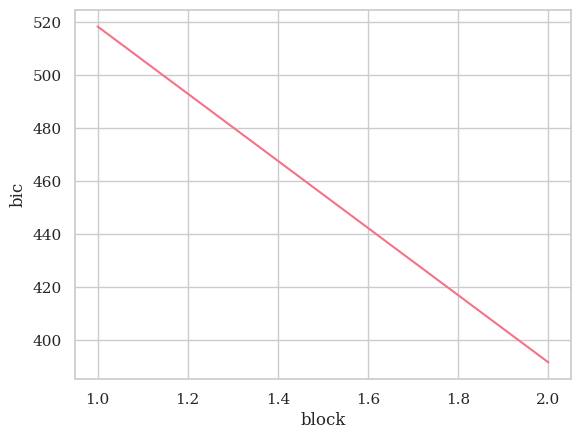

<Axes: xlabel='block', ylabel='mse'>

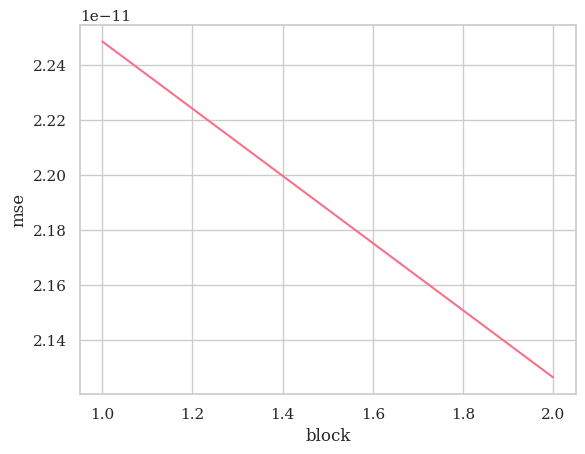

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=bttda.train_info_, x='block', y='bic')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='mse')

No projector specified for this dataset. Please consider the method self.add_proj.


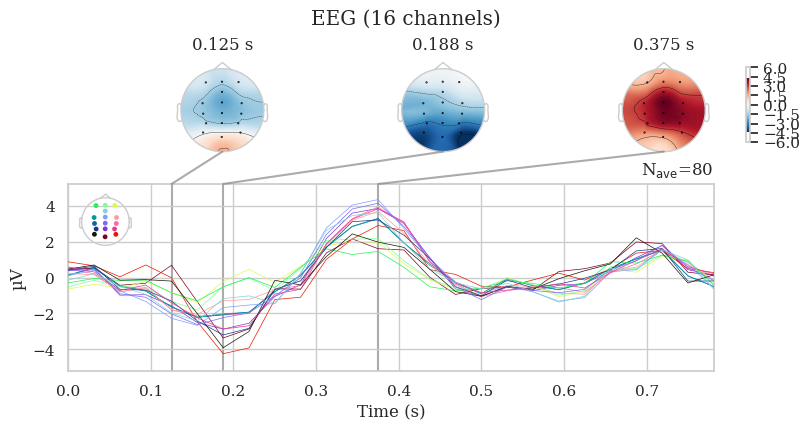

In [16]:
from mne import combine_evoked
import numpy as np
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
vmax = np.max(np.abs(contrast.data))*1.2*1e6
joint_args=dict(ts_args=dict(ylim=dict(eeg=[-vmax, vmax])))
_ = contrast.plot_joint(**joint_args)

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_897/3179974677.py:8: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X_defl = hankel_tensor(epochs.get_data())
/tmp/ipykernel_897/3179974677.py:10: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = np.zeros_like(epochs_rec.get_data())


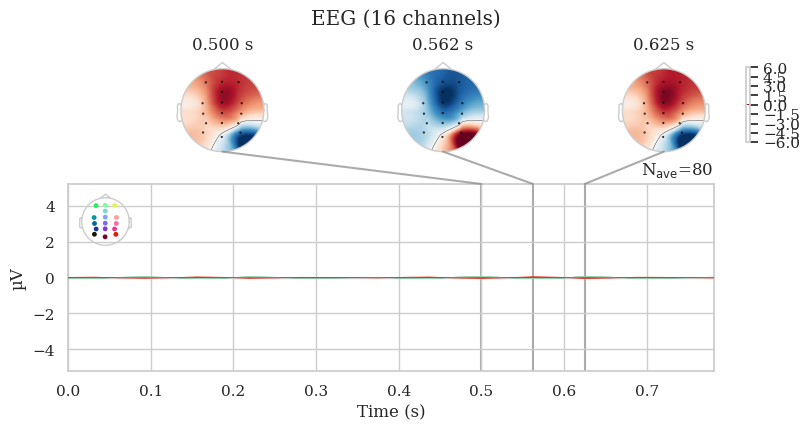

No projector specified for this dataset. Please consider the method self.add_proj.


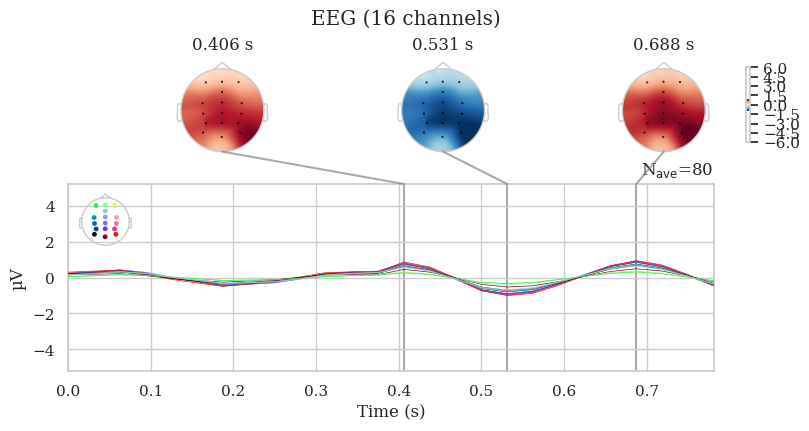

In [20]:
from mne import combine_evoked
from hoda.hoda import mse
from mne.viz import plot_compare_evokeds
from hoda.tensorize import hankel_tensor_inv
import numpy as np


X_defl = hankel_tensor(epochs.get_data())
epochs_rec = epochs.copy()
epochs_rec._data = np.zeros_like(epochs_rec.get_data())
evokeds = dict()
for b in range(len(bttda.blocks_)):
    epochs_block_rec = epochs.copy()
    Xb =  tl.to_numpy(bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(X_defl)))
    epochs_block_rec._data =hankel_tensor_inv(Xb)
    X_defl -= Xb
    epochs_rec._data += epochs_block_rec._data
    
    target_block_rec = epochs_block_rec['Target'].average()
    non_target_block_rec = epochs_block_rec['NonTarget'].average()
    contrast_block_rec = combine_evoked([target_block_rec,non_target_block_rec], weights=[1,-1])
    evokeds[f'block {b}'] =contrast_block_rec
    contrast_block_rec.plot_joint(**joint_args)